In [1]:
import sys
!{sys.executable} -m pip install opencv-python scikit-learn scikit-image numpy matplotlib seaborn imutils 

In [2]:
import cv2
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.pipeline import Pipeline
import pickle

print("All imports successful.")

All imports successful.


In [3]:
GESTURES = [
    'open_hand',
    'fist',
    'thumbs_up',
    'peace',
    'pointing'
]

# Dataset directory
DATASET_DIR = 'gesture_dataset'

# Number of images to capture per gesture
IMAGES_PER_GESTURE = 200

# Image dimensions for resizing
IMG_SIZE = (128, 128)

# HOG parameters
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)

# Model save path
MODEL_SAVE_PATH = 'gesture_model.pkl'
SCALER_SAVE_PATH = 'gesture_scaler.pkl'
ENCODER_SAVE_PATH = 'gesture_encoder.pkl'

# Create dataset directory structure
os.makedirs(DATASET_DIR, exist_ok=True)
for gesture in GESTURES:
    os.makedirs(os.path.join(DATASET_DIR, gesture), exist_ok=True)

print(f"Dataset directory: {DATASET_DIR}")
print(f"Gestures to capture: {GESTURES}")
print(f"Images per gesture: {IMAGES_PER_GESTURE}")

Dataset directory: gesture_dataset
Gestures to capture: ['open_hand', 'fist', 'thumbs_up', 'peace', 'pointing']
Images per gesture: 200


In [4]:
def preprocess_frame(frame):
    """
    Preprocess a raw webcam frame:
    - Convert to YCrCb color space for better skin detection
    - Apply Gaussian blur
    - Create a skin mask
    - Morphological operations to clean up the mask
    - Return both the mask and a region of interest (ROI)
    """
    # Define ROI box on frame
    roi_top, roi_bottom, roi_left, roi_right = 50, 350, 300, 650
    roi = frame[roi_top:roi_bottom, roi_left:roi_right]

    # Blur to reduce noise
    blurred = cv2.GaussianBlur(roi, (5, 5), 0)

    # Convert to YCrCb for skin detection
    ycrcb = cv2.cvtColor(blurred, cv2.COLOR_BGR2YCrCb)

    # Skin color range in YCrCb
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    skin_mask = cv2.inRange(ycrcb, lower_skin, upper_skin)

    # Also use HSV skin range for better coverage
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
    lower_hsv = np.array([0, 20, 70], dtype=np.uint8)
    upper_hsv = np.array([20, 255, 255], dtype=np.uint8)
    hsv_mask = cv2.inRange(hsv, lower_hsv, upper_hsv)

    # Combine masks
    combined_mask = cv2.bitwise_or(skin_mask, hsv_mask)

    # Morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    combined_mask = cv2.dilate(combined_mask, kernel, iterations=1)

    # Apply mask to ROI
    segmented = cv2.bitwise_and(roi, roi, mask=combined_mask)

    return roi, combined_mask, segmented


def prepare_image_for_saving(mask):
    """
    Resize the binary mask to IMG_SIZE for consistent storage.
    """
    resized = cv2.resize(mask, IMG_SIZE)
    return resized


print("Preprocessing functions defined.")

Preprocessing functions defined.


In [5]:
def capture_dataset(gestures, dataset_dir, images_per_gesture):
    """
    Capture and save labeled gesture images from webcam.
    For each gesture:
      - Display a live preview with ROI box
      - Wait for user to press 'S' to start capturing
      - Save skin-masked images to the appropriate folder
    """
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("ERROR: Cannot open webcam. Check camera connection.")
        return

    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 720)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    for gesture in gestures:
        save_dir = os.path.join(dataset_dir, gesture)
        existing = len(os.listdir(save_dir))

        if existing >= images_per_gesture:
            print(f"[SKIP] '{gesture}' already has {existing} images.")
            continue

        count = existing
        capturing = False
        print(f"\n[GESTURE] '{gesture}' | Existing: {existing} | Target: {images_per_gesture}")
        print("  -> Position your hand in the GREEN box.")
        print("  -> Press 'S' to start capturing, 'Q' to skip this gesture.")

        while True:
            ret, frame = cap.read()
            if not ret:
                print("Failed to grab frame.")
                break

            frame = cv2.flip(frame, 1)
            display = frame.copy()

            # Draw ROI rectangle
            roi_top, roi_bottom, roi_left, roi_right = 50, 350, 300, 650
            color = (0, 255, 0) if not capturing else (0, 0, 255)
            cv2.rectangle(display, (roi_left, roi_top), (roi_right, roi_bottom), color, 2)

            # Status text
            status = f"Gesture: {gesture} | Captured: {count}/{images_per_gesture}"
            cv2.putText(display, status, (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

            if not capturing:
                cv2.putText(display, "Press 'S' to start | 'Q' to skip",
                            (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
            else:
                cv2.putText(display, "CAPTURING...",
                            (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

            # Show mask preview in corner
            _, mask, _ = preprocess_frame(frame)
            mask_small = cv2.resize(mask, (150, 150))
            mask_bgr = cv2.cvtColor(mask_small, cv2.COLOR_GRAY2BGR)
            display[roi_top:roi_top+150, 0:150] = mask_bgr
            cv2.putText(display, "Mask", (5, roi_top + 165),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

            cv2.imshow('Dataset Capture', display)

            key = cv2.waitKey(1) & 0xFF

            if key == ord('s') or key == ord('S'):
                capturing = True

            if key == ord('q') or key == ord('Q'):
                print(f"  -> Skipped '{gesture}'.")
                break

            if capturing:
                _, save_mask, _ = preprocess_frame(frame)
                img_to_save = prepare_image_for_saving(save_mask)
                filename = os.path.join(save_dir, f"{gesture}_{count:04d}.png")
                cv2.imwrite(filename, img_to_save)
                count += 1

                if count >= images_per_gesture:
                    print(f"  -> Captured {images_per_gesture} images for '{gesture}'.")
                    time.sleep(1)
                    break

    cap.release()
    cv2.destroyAllWindows()
    print("\nDataset capture complete!")


# RUN CAPTURE — comment this out if you already have images
# capture_dataset(GESTURES, DATASET_DIR, IMAGES_PER_GESTURE)

In [6]:
print("Dataset Summary:")
print("-" * 40)
total = 0
for gesture in GESTURES:
    folder = os.path.join(DATASET_DIR, gesture)
    count = len([f for f in os.listdir(folder) if f.endswith('.png')])
    total += count
    print(f"  {gesture:20s}: {count} images")
print("-" * 40)
print(f"  {'TOTAL':20s}: {total} images")

Dataset Summary:
----------------------------------------
  open_hand           : 200 images
  fist                : 200 images
  thumbs_up           : 200 images
  peace               : 200 images
  pointing            : 200 images
----------------------------------------
  TOTAL               : 1000 images


In [7]:
def extract_hog_features(img):
    """
    Extract Histogram of Oriented Gradients (HOG) features.
    HOG captures edge/shape structure of the hand silhouette.
    """
    features = hog(
        img,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        visualize=False
    )
    return features


def extract_hu_moments(img):
    """
    Extract Hu Moments (7 values), which are shape descriptors
    invariant to translation, scale, and rotation.
    """
    moments = cv2.moments(img)
    hu = cv2.HuMoments(moments).flatten()
    # Log-transform for better numerical behavior
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    return hu


def extract_contour_features(img):
    """
    Extract geometric contour and convex hull features:
    - Contour area, perimeter, bounding box aspect ratio
    - Convexity defects count (finger gaps)
    - Solidity (area / hull area)
    - Extent (area / bounding rect area)
    - Convex hull perimeter vs contour perimeter ratio
    """
    features = np.zeros(12)

    contours, _ = cv2.findContours(
        img.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return features

    # Largest contour
    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)

    if area < 100:
        return features

    perimeter = cv2.arcLength(cnt, True)
    x, y, w, h = cv2.boundingRect(cnt)

    # Convex hull
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    hull_perimeter = cv2.arcLength(hull, True)

    solidity = area / (hull_area + 1e-5)
    extent = area / (w * h + 1e-5)
    aspect_ratio = w / (h + 1e-5)
    hull_ratio = hull_perimeter / (perimeter + 1e-5)

    # Convexity defects (finger valleys)
    defect_count = 0
    mean_defect_depth = 0
    try:
        hull_idx = cv2.convexHull(cnt, returnPoints=False)
        if hull_idx is not None and len(hull_idx) > 3:
            defects = cv2.convexityDefects(cnt, hull_idx)
            if defects is not None:
                for defect in defects:
                    s, e, f, d = defect[0]
                    depth = d / 256.0
                    if depth > 10:
                        defect_count += 1
                        mean_defect_depth += depth
                if defect_count > 0:
                    mean_defect_depth /= defect_count
    except Exception:
        pass

    # Circularity
    circularity = (4 * np.pi * area) / (perimeter ** 2 + 1e-5)

    # Equivalent diameter
    equiv_diameter = np.sqrt(4 * area / np.pi)

    features = np.array([
        area / (IMG_SIZE[0] * IMG_SIZE[1]),  # normalized area
        perimeter / (2 * (IMG_SIZE[0] + IMG_SIZE[1])),  # normalized perimeter
        aspect_ratio,
        solidity,
        extent,
        hull_ratio,
        circularity,
        equiv_diameter / IMG_SIZE[0],
        defect_count,
        mean_defect_depth / 100.0,
        w / IMG_SIZE[0],  # normalized width
        h / IMG_SIZE[1],  # normalized height
    ])

    return features


def extract_pixel_histogram(img):
    """
    Extract a pixel-based histogram of the binary mask image.
    Divides the image into a 4x4 grid and computes the
    white pixel ratio per cell to capture spatial distribution.
    """
    grid = 4
    cell_h = img.shape[0] // grid
    cell_w = img.shape[1] // grid
    features = []
    for i in range(grid):
        for j in range(grid):
            cell = img[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
            ratio = np.sum(cell > 0) / (cell_h * cell_w + 1e-5)
            features.append(ratio)
    return np.array(features)


def extract_all_features(img):
    """
    Combine all feature extractors into one feature vector:
    HOG + Hu Moments + Contour Features + Spatial Grid Histogram
    """
    hog_feats = extract_hog_features(img)
    hu_feats = extract_hu_moments(img)
    contour_feats = extract_contour_features(img)
    hist_feats = extract_pixel_histogram(img)

    return np.concatenate([hog_feats, hu_feats, contour_feats, hist_feats])


print("Feature extraction functions defined.")

# Show feature vector size with a dummy image
dummy = np.zeros(IMG_SIZE, dtype=np.uint8)
sample_features = extract_all_features(dummy)
print(f"Feature vector size: {sample_features.shape[0]}")

Feature extraction functions defined.
Feature vector size: 8135


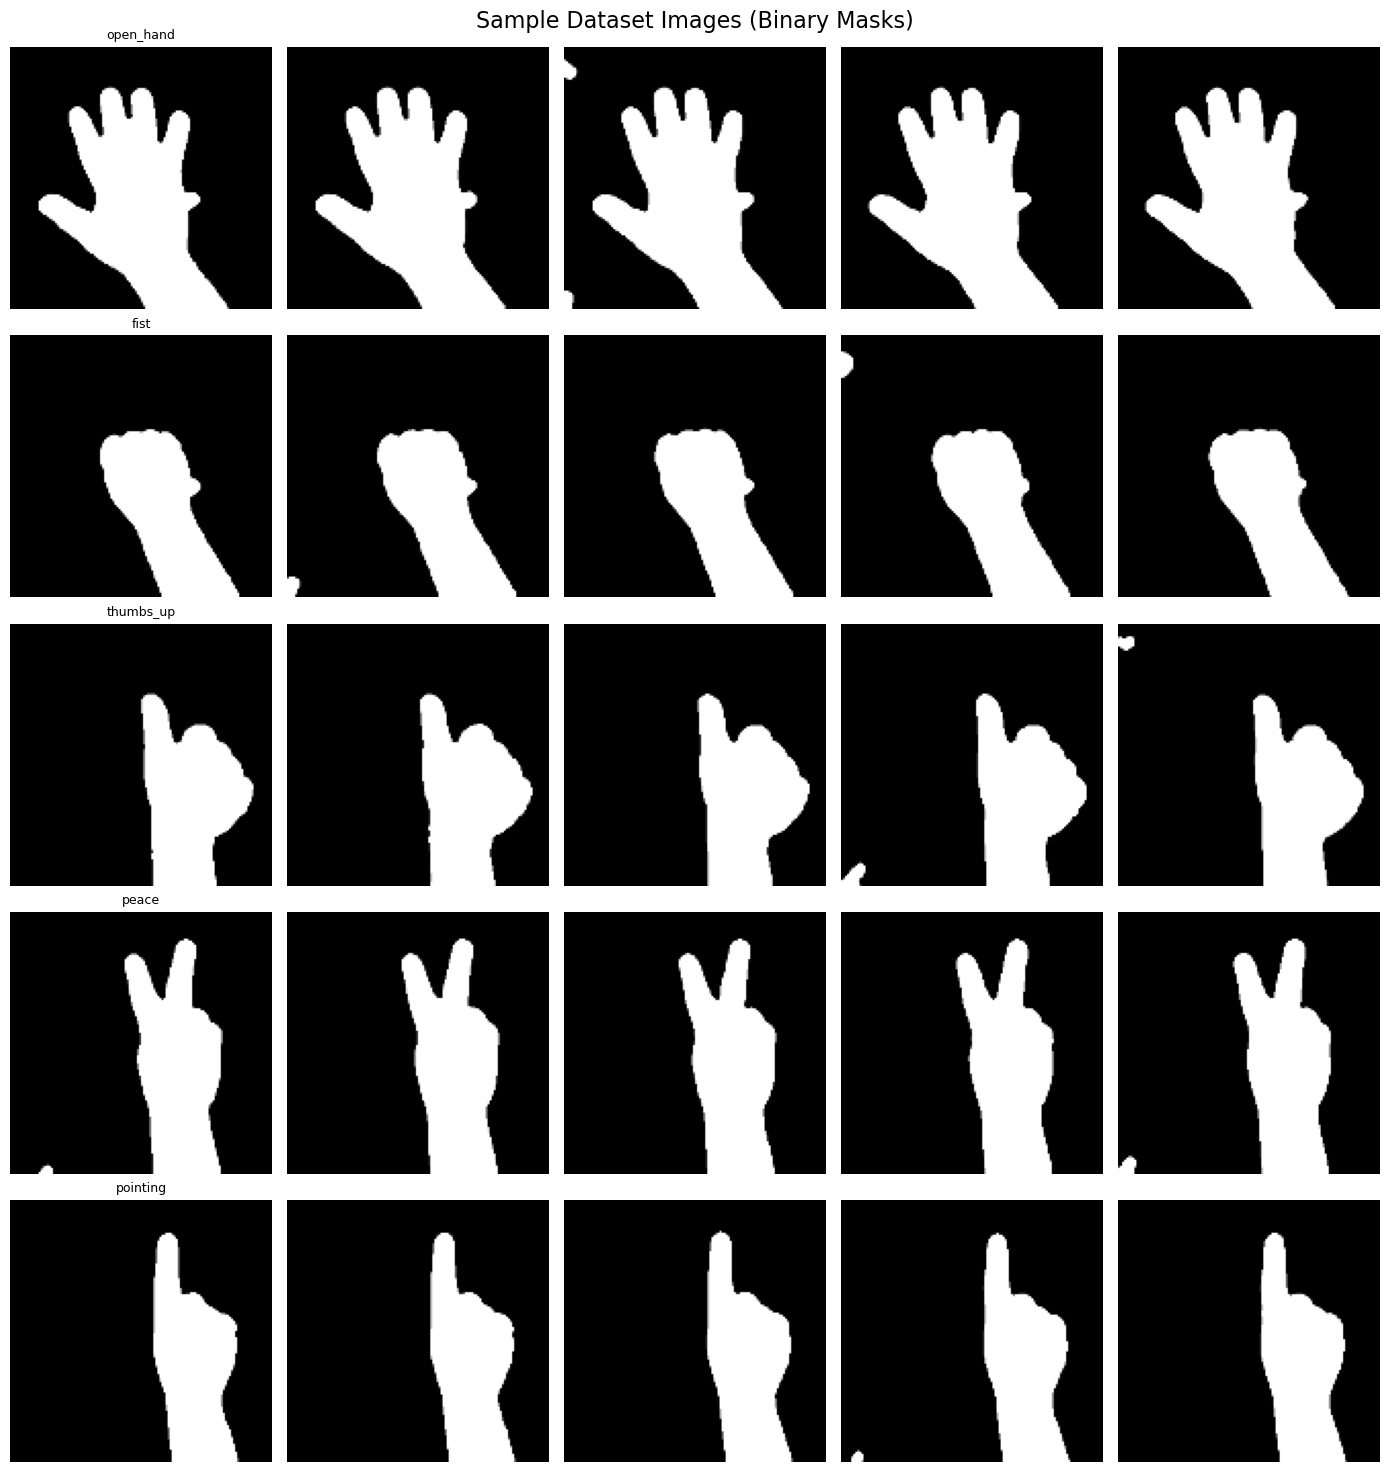

Dataset sample plot saved as 'dataset_samples.png'


In [8]:
fig, axes = plt.subplots(len(GESTURES), 5, figsize=(14, 3 * len(GESTURES)))
fig.suptitle('Sample Dataset Images (Binary Masks)', fontsize=16)

for row, gesture in enumerate(GESTURES):
    folder = os.path.join(DATASET_DIR, gesture)
    files = sorted([f for f in os.listdir(folder) if f.endswith('.png')])
    sample_files = files[:5] if len(files) >= 5 else files

    for col, fname in enumerate(sample_files):
        img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        ax = axes[row][col]
        ax.imshow(img, cmap='gray')
        ax.set_title(gesture if col == 0 else '', fontsize=9)
        ax.axis('off')

    # Fill empty columns if fewer than 5 images
    for col in range(len(sample_files), 5):
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('dataset_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print("Dataset sample plot saved as 'dataset_samples.png'")

In [9]:
def load_and_extract_features(dataset_dir, gestures):
    X = []  # Feature matrix
    y = []  # Labels

    print("Loading dataset and extracting features...")
    for i, gesture in enumerate(gestures):
        path = os.path.join(dataset_dir, gesture)
        images = os.listdir(path)
        print(f"  Processing '{gesture}' ({len(images)} images)")

        for img_name in images:
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"Warning: Could not load image {img_path}")
                continue

            features = extract_all_features(img)
            X.append(features)
            y.append(gesture) # Store gesture name as label

    print("Feature extraction complete.")
    return np.array(X), np.array(y)

X, y = load_and_extract_features(DATASET_DIR, GESTURES)
print(f"Feature matrix shape: {X.shape}")
print(f"Label distribution: { {g: np.sum(y == g) for g in GESTURES} }")

Loading dataset and extracting features...
  Processing 'open_hand' (200 images)
  Processing 'fist' (200 images)
  Processing 'thumbs_up' (200 images)
  Processing 'peace' (200 images)
  Processing 'pointing' (200 images)
Feature extraction complete.
Feature matrix shape: (1000, 8135)
Label distribution: {'open_hand': np.int64(200), 'fist': np.int64(200), 'thumbs_up': np.int64(200), 'peace': np.int64(200), 'pointing': np.int64(200)}


In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Label encoding: { dict(zip(le.classes_, le.transform(le.classes_))) }")

# Train-test split (80% train, 20% test), stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

# Feature scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling applied (StandardScaler).")

# Save scaler and encoder for real-time prediction
with open(SCALER_SAVE_PATH, 'wb') as f:
    pickle.dump(scaler, f)

with open(ENCODER_SAVE_PATH, 'wb') as f:
    pickle.dump(le, f)

print(f"Scaler saved to '{SCALER_SAVE_PATH}'")
print(f"Encoder saved to '{ENCODER_SAVE_PATH}'")

Label encoding: {np.str_('fist'): np.int64(0), np.str_('open_hand'): np.int64(1), np.str_('peace'): np.int64(2), np.str_('pointing'): np.int64(3), np.str_('thumbs_up'): np.int64(4)}
Training samples : 800
Testing samples  : 200
Feature scaling applied (StandardScaler).
Scaler saved to 'gesture_scaler.pkl'
Encoder saved to 'gesture_encoder.pkl'


In [11]:
models = {
    'SVM (RBF)': SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        probability=True,
        random_state=42
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=7,
        weights='distance',
        metric='euclidean'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=20,
        min_samples_split=5,
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='lbfgs',
        multi_class='multinomial',
        random_state=42
    )
}

results = {}

print("Training models...")
print("=" * 60)

for name, model in models.items():
    print(f"\nTraining: {name}")
    start = time.time()
    model.fit(X_train_scaled, y_train)
    elapsed = time.time() - start

    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    # 5-fold cross-validation on training set
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'model': model,
        'accuracy': acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'train_time': elapsed
    }

    print(f"  Test Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  CV Accuracy    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Training Time  : {elapsed:.2f}s")

print("\n" + "=" * 60)
print("All models trained.")

# ----- Save the best model (Random Forest) -----
import pickle
# Choose the model you want to keep.
# Here we pick the Random Forest model, which achieved 100 % test accuracy.
best_model = results['Random Forest']['model']
# Save the model to the path defined earlier in the notebook.
with open(MODEL_SAVE_PATH, 'wb') as f:
    pickle.dump(best_model, f)
print(f"Model saved to '{MODEL_SAVE_PATH}'")

Training models...

Training: SVM (RBF)
  Test Accuracy  : 0.9950 (99.50%)
  CV Accuracy    : 0.9888 ± 0.0061
  Training Time  : 4.03s

Training: K-Nearest Neighbors
  Test Accuracy  : 1.0000 (100.00%)
  CV Accuracy    : 1.0000 ± 0.0000
  Training Time  : 0.00s

Training: Random Forest
  Test Accuracy  : 1.0000 (100.00%)
  CV Accuracy    : 1.0000 ± 0.0000
  Training Time  : 0.17s

Training: Decision Tree
  Test Accuracy  : 1.0000 (100.00%)
  CV Accuracy    : 0.9925 ± 0.0061
  Training Time  : 0.11s

Training: Logistic Regression
  Test Accuracy  : 1.0000 (100.00%)
  CV Accuracy    : 1.0000 ± 0.0000
  Training Time  : 2.73s

All models trained.
Model saved to 'gesture_model.pkl'


In [12]:
# REAL-TIME WEBCAM TEST
import cv2
import numpy as np
import pickle
import time
from IPython.display import clear_output

# Load the saved model, scaler, and encoder
MODEL_SAVE_PATH = 'gesture_model.pkl'
SCALER_SAVE_PATH = 'gesture_scaler.pkl'
ENCODER_SAVE_PATH = 'gesture_encoder.pkl'

with open(MODEL_SAVE_PATH, 'rb') as f:
    svm_model = pickle.load(f)
with open(SCALER_SAVE_PATH, 'rb') as f:
    scaler = pickle.load(f)
with open(ENCODER_SAVE_PATH, 'rb') as f:
    label_encoder = pickle.load(f)

def run_realtime_test():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("ERROR: Cannot open webcam.")
        return

    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 720)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    print("Starting real-time gesture recognition. Press 'Q' to quit.")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame.")
            break
            
        frame = cv2.flip(frame, 1)
        display = frame.copy()
        
        # Define ROI top, bottom, left, right (same as in preprocessing)
        roi_top, roi_bottom, roi_left, roi_right = 50, 350, 300, 650
        cv2.rectangle(display, (roi_left, roi_top), (roi_right, roi_bottom), (0, 255, 0), 2)
        
        # Process the frame to get the mask
        _, mask, _ = preprocess_frame(frame)
        
        try:
            # Resize mask for feature extraction
            img_resized = prepare_image_for_saving(mask)
            
            # Extract features
            features = extract_all_features(img_resized)
            
            # Scale features
            features_scaled = scaler.transform([features])
            
            # Predict
            pred = svm_model.predict(features_scaled)
            gesture_name = label_encoder.inverse_transform(pred)[0]
            
            # Show prediction
            cv2.putText(display, f"Prediction: {gesture_name}", (10, 30), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
        except Exception as e:
            cv2.putText(display, "Prediction: Error/No Hand", (10, 30), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
        
        # Show mask preview in corner
        mask_small = cv2.resize(mask, (150, 150))
        mask_bgr = cv2.cvtColor(mask_small, cvq2.COLOR_GRAY2BGR)
        display[roi_top:roi_top+150, 0:150] = mask_bgr
        cv2.putText(display, "Mask", (5, roi_top + 165),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        cv2.imshow('Real-time Gesture Recognition', display)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q') or key == ord('Q'):
            break

    cap.release()
    cv2.destroyAllWindows()

# Uncomment the line below to run the real-time test
run_realtime_test()


Starting real-time gesture recognition. Press 'Q' to quit.
